# Bat Echolocation Feature Extraction
Goal: Extract features from bat echolocation calls, remove outliers, then average across all calls in a bat pass

--> Program is semi-automated, so you run cells at the top and then add filename and adjust thresholds until the calls are correctly highlighted using the waveform/spectrogram, then run the rest of the program and it will export your results in a csv.

Steps:
1. Input a file
2. Apply filter to remove lower-frequency background noise below the bat calls
3. Normalize amplitude
4. Visualize
5. Use voice activity detection (VAD) with energy cutoff to get the timestamps for the bat calls and inter-call intervals (ICIs)
6. For each call within the bat pass (excluding first and last which could be cut off), extract the following features:
    - start time
    - end time
    - call duration
    - time until the next call
    - min frequency
    - max frequency
    - frequency of most energy
    - slope estimate assuming downward shape
7. Show those results in a table, with each column being a feature, and each row being a call
8. Check for outliers on each feature and remove calls with outliers
9. Check for presence of feeding buzzes, and extract the duration and min_freq in the feeding buzz
10. Get averages for the features and prep for export

In [61]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore

## Helper Methods

In [12]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=sr, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [13]:
# Create method to easily plot spectrograms
def plot_spectrogram(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [14]:
# Create method to easily plot spectrograms AND zoom in on the x-axis
def plot_spectrogram_zoom(Y, sr, hop_length, y_axis="mel", fmin=0, fmax=20000, xmin=0, xmax=12):
    plt.figure(figsize=(25, 10)) # instantiate a figure and give a size
    # use librosa.display.specshow to visualize any type of spectrogram
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis
		)
    plt.ylim(fmin, fmax)
    plt.xlim(xmin, xmax)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')    
    plt.colorbar(format="%+2.f") # add a color bar legend
    plt.title('Spectrogram')
    plt.show()

In [15]:
# normalize audio signal so volume is consistent across files
def rms_normalize(y, target_dBFS=-30.0):
    rms = np.sqrt(np.mean(y**2))
    current_dBFS = 20 * np.log10(rms + 1e-9)
    gain = 10 ** ((target_dBFS - current_dBFS) / 20)
    return y * gain

In [16]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that separates a group of sound
# Returns periods of time with voice activity separated by silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_voice_activity_timestamps(*, vad_output: List[int], frame_shift: int, min_silence_duration: int = 1000):
    min_silence_frames = int(min_silence_duration / frame_shift)

    groups = []
    start_idx = None
    silence_counter = 0

    for i, frame in enumerate(vad_output):
        if frame == 1:
            if start_idx is None:
                start_idx = i
            silence_counter = 0
        else:
            if start_idx is not None:
                silence_counter += 1
                if silence_counter >= min_silence_frames:
                    # Silence is long enough, so close the current voice group
                    end_idx = i - silence_counter
                    start_time = start_idx * frame_shift / 1000
                    end_time = (end_idx + 1) * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 4),
                        'end': round(end_time, 4)
                    })
                    start_idx = None
                    silence_counter = 0

    # Handle case where audio ends with voice activity
    if start_idx is not None:
        end_time = (len(vad_output)+1) * frame_shift / 1000
        groups.append({
            'start': round(start_idx * frame_shift / 1000, 4),
            'end': round(end_time, 4)
        })

    return groups

In [17]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that will be included
# Returns timestamps for silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_timestamps_silences(*, vad_output: List[int], frame_shift: int, min_silence_duration: int=1000):
    min_silence_frames = int(min_silence_duration / frame_shift)
    groups = []
    start_idx = None

    for i, frame in enumerate(vad_output):
        if frame==0:
            if start_idx is None:
                start_idx = i
        else:
            if start_idx is not None:
                end_idx = i
                duration = end_idx - start_idx

                if duration >= min_silence_frames:
                    start_time = start_idx * frame_shift / 1000
                    end_time = end_idx * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 2),
                        'end': round(end_time, 2)
                    })

                start_idx = None

    # Handle case where the last segment goes to the end
    if start_idx is not None:
        end_idx = len(vad_output)
        duration = end_idx - start_idx
        if duration >= min_silence_frames:
            start_time = start_idx * frame_shift / 1000
            end_time = end_idx * frame_shift / 1000
            groups.append({
                'start': round(start_time, 2),
                'end': round(end_time, 2)
            })

    return groups

In [18]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

In [19]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps, sr):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * sr) # convert start time into sample index
        end_sample = int(float(ts['end']) * sr)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [20]:
# Function that takes in:
    #   stft_abs which comes from stft = librosa.stft() && stft_abs = np.abs(stft_bat) 
    #   and where filters for background noise have already been applied
    #   times, which comes from librosa.frames_to_time()
    #   the start and end times (in seconds) of the call
    #   an energy cutoff, for instance, what's the minimum energy that something has to have
    #   to be considered part of the sound
# Function returns the min frequency, the max frequency, and the frequency with most energy (Hz)
def extractMinMaxAndMostEnergyFrequencies(stft_abs, times, start_time, end_time, energy_cutoff, bat_frequencies):
    # slice time window for the first bat call
    time_mask = (times >= start_time) & (times <= end_time)
    stft_call = stft_abs[:, time_mask]
    
    # energy per frequency bin
    energy_per_freq = stft_call.mean(axis=1)

    # normalize
    energy_norm = energy_per_freq / energy_per_freq.max()

    # cutoff mask
    mask = energy_norm >= energy_cutoff

    # get results
    min_freq = bat_frequencies[mask].min()
    max_freq = bat_frequencies[mask].max()
    max_energy_freq = bat_frequencies[np.argmax(energy_per_freq)]

    # return results
    return {'min_freq': min_freq, 'max_freq': max_freq, 'max_energy_freq': max_energy_freq}

## File input and Thresholds to adjust

In [1082]:
filename = 'XC837607 - Pallid Bat - Antrozous pallidus.wav'
sr = 384000
# Cutoff to zero out frequencies below bat sounds --> adjust after checking spectrogram
CUTOFF = 20000 # Hz # default is 20000

# Spectrogram visualization settings
SPECTROGRAM_MIN_FREQ = CUTOFF
SPECTROGRAM_MAX_FREQ = 100000

# VAD Settings --> adjust these depending on how fast the bat is making sounds
FRAME_LENGTH = 5 # milliseconds
FRAME_SHIFT = 2 # milliseconds
# Generally a silence longer than 90ms is should separate one search call from another
MIN_ICI = 20 # in milliseconds
# call might be 19ms (3-50ms) or 0.5ms for micro-calls, while a ICI might be like 228ms
# Search phase ICI's are ~100 ms or longer
# Approach phase ICI's are ~20 ms
# Feeding buzz ICI's are ~9-18 ms

In [1083]:
# Load audio with Librosa.load and sample at the correct rate
file, sr = librosa.load(filename, sr=sr)
# Apply the Short-Time Fourier Transform to convert to the frequency domain
FRAME_LENGTH_SPEC = 2048
HOP_LENGTH_SPEC = FRAME_LENGTH_SPEC//4
stft_bat = librosa.stft(file, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat.shape
stft_bat_abs = np.abs(stft_bat) ** 2

In [1084]:
# Filter out lower frequency background noise by zeroing out all values below a cutoff
bat_frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH_SPEC)
cutoff_idx = np.argmax(bat_frequencies >= CUTOFF)
stft_bat_filtered = stft_bat.copy()
stft_bat_filtered[:cutoff_idx, :] = 0
stft_bat_filtered_abs = np.abs(stft_bat_filtered) ** 2
bat_filtered = librosa.istft(stft_bat_filtered, hop_length=HOP_LENGTH_SPEC)

In [1085]:
# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
bat_filtered_normalized = rms_normalize(bat_filtered, target_dBFS=-30.0)
stft_bat = librosa.stft(bat_filtered_normalized, n_fft=FRAME_LENGTH_SPEC, hop_length=HOP_LENGTH_SPEC)
stft_bat_filtered_abs = np.abs(stft_bat) ** 2
stft_bat_filtered_dB = librosa.power_to_db(np.abs(stft_bat_filtered_abs), ref=np.max)

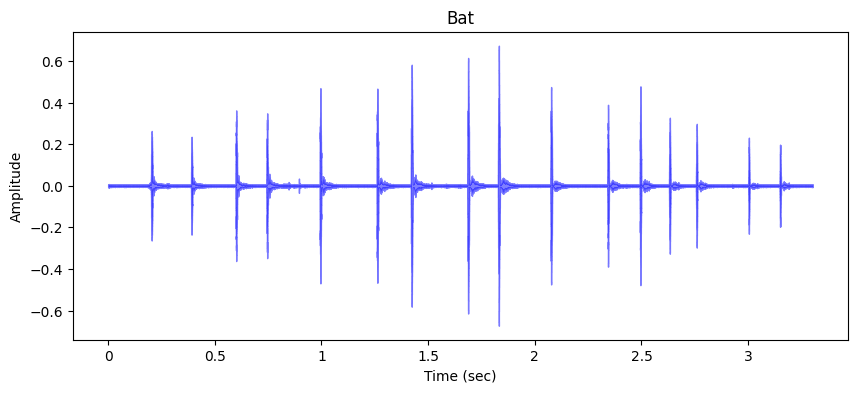

In [1086]:
# Plot waveform
plotWaveform(bat_filtered_normalized, 'Bat')

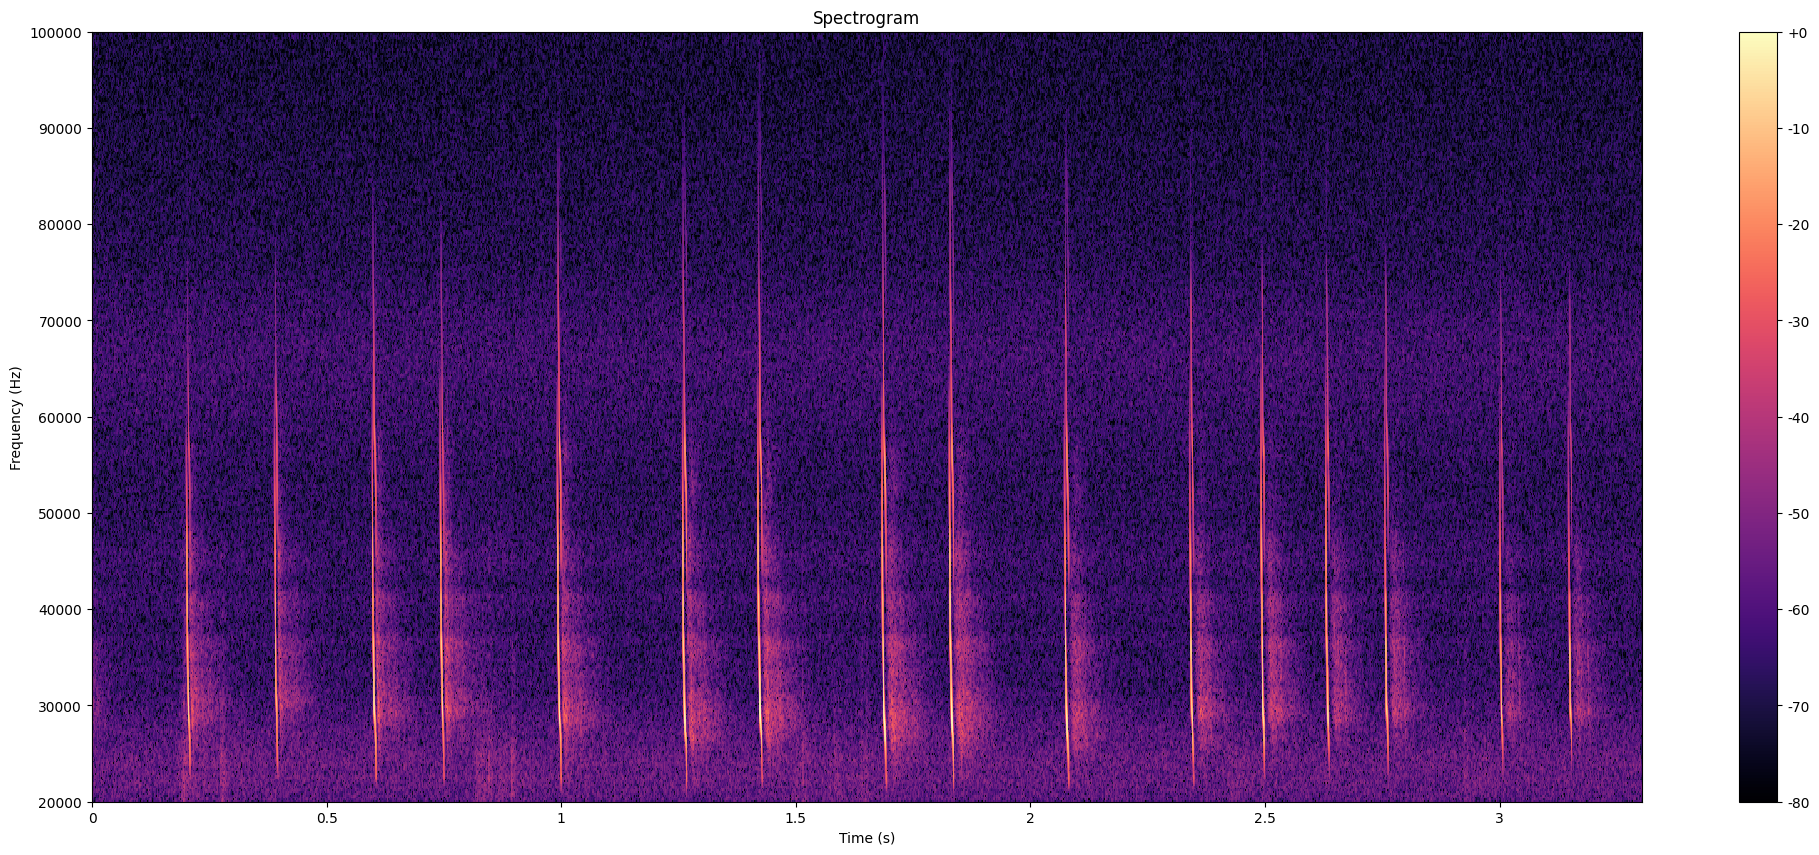

In [1087]:
# Plot spectrogram
plot_spectrogram(
    stft_bat_filtered_dB,
    sr,
    HOP_LENGTH_SPEC,
    "linear",
    SPECTROGRAM_MIN_FREQ,
    SPECTROGRAM_MAX_FREQ)

In [1088]:
# !!! Help picking an energy threshold
# fill out the number of expected calls you'd expect to see based on the waveform and
# spectrogram that are LOUDER than wind. Include non-call sounds that are as 
# loud as the calls and above the frequency cutoff --> these will be removed later 
# if they're outliers
NUM_OF_CALLS = 16

In [1089]:
# Automated choosing energy threshold based on user estimate of
# number of calls, using lowest possible energy threshold that gets
# close to that number.
# Goal is for the program to correctly highlight the calls below
energy_threshold = 0.01
num_of_calls = 0
max_runs = 100
run = 0

while num_of_calls < NUM_OF_CALLS - 3 and run < max_runs:
    
    # energy_threshold += 0.01
    energy_threshold = energy_threshold + 0.01
    vad = EnergyVAD(
        frame_length=FRAME_LENGTH,
        frame_shift=FRAME_SHIFT,
        sample_rate=sr,
        energy_threshold=energy_threshold)
    vad_output = vad(bat_filtered_normalized)
    # Get timestamps for calls
    calls = get_voice_activity_timestamps(
        vad_output=vad_output,
        frame_shift=FRAME_SHIFT,
        min_silence_duration=MIN_ICI)
    num_of_calls = len(calls)
    run += 1
print(f'Energy threshold should be at least: {energy_threshold:2f} identified {len(calls)} calls but raise as needed')
ENERGY_THRESHOLD = energy_threshold

Energy threshold should be at least: 0.020000 identified 16 calls but raise as needed


In [1090]:
# re-adjust energy threshold as needed to make sure waveform below makes sense
# ENERGY_THRESHOLD = 1.5

In [1091]:
# VAD
vad = EnergyVAD(
    frame_length=FRAME_LENGTH,
    frame_shift=FRAME_SHIFT,
    sample_rate=sr,
    energy_threshold=ENERGY_THRESHOLD)
vad_output = vad(bat_filtered_normalized)
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)

# Get timestamps for silences between calls
icis = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_ICI)
# If the first ICI starts at 0, cut it off since we don't want that at the beginning
if len(icis) > 0 and icis[0]['start'] == 0:
    icis = icis[1:]
print(f'Identified {len(calls)} call(s) and {len(icis)} silences')
if len(calls) < 4:
    print('Error! This is not enough calls. Try increasing the ENERGY_THRESHOLD')

Identified 16 call(s) and 16 silences


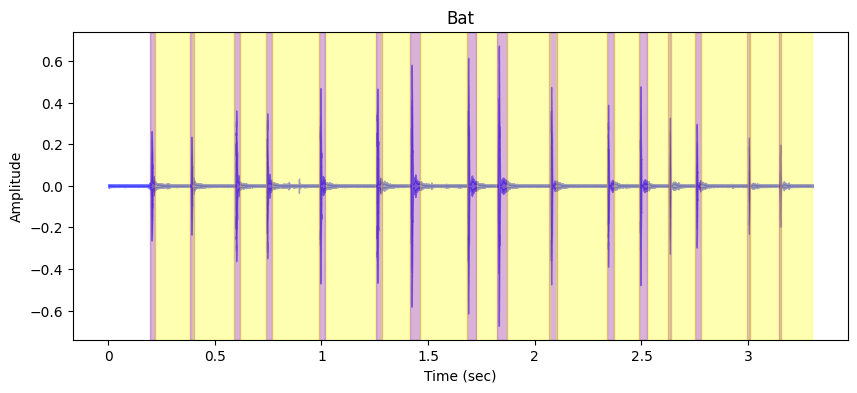

In [1092]:
plotWaveform(bat_filtered_normalized, 'Bat', calls, icis)

In [1093]:
# If there are more calls than ICI's, cut the last call out
if len(calls) > len(icis):
    calls = calls[:-1]

In [1094]:
# Extract time data
starts = []
ends = []
durations_ms = []
for call in calls:
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)
start_end_data = {'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)
# Add time_to_next_call_ms to the dataframe
time_to_next_call_ms = []
for ici in icis:
    time_to_next_call_ms.append((ici['end'] - ici['start']) * 1000)
df['time_to_next_call_ms'] = time_to_next_call_ms

In [1095]:
# Frequency domain data
times = librosa.frames_to_time(np.arange(stft_bat_filtered_abs.shape[1]),
                               sr=sr,
                               hop_length=HOP_LENGTH_SPEC)
frequency_data = []
for call in calls:
    energy_cutoff = 0.04
    call_data = extractMinMaxAndMostEnergyFrequencies(
        stft_bat_filtered_abs,
        times,
        call['start'],
        call['end'],
        energy_cutoff,
        bat_frequencies)
    frequency_data.append(call_data)
# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
# Calculate simple slopes for all calls and add to table
df['slope'] = (df['min_freq'] - df['max_freq']) / ((df['end'] - df['start']) * 1000)
df.head()

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.196,0.220,24.0,160.0,25687.5,47812.5,30187.5,-921.875000
1,0.384,0.404,20.0,190.0,24562.5,52125.0,30562.5,-1378.125000
2,0.592,0.616,24.0,120.0,25500.0,48000.0,29250.0,-937.500000
3,0.738,0.766,28.0,220.0,26437.5,48375.0,29812.5,-783.482143
4,0.988,1.018,30.0,230.0,26250.0,57187.5,28687.5,-1031.250000


In [1096]:
# Check df
df

,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
0,0.196,0.220,24.0,160.0,25687.5,47812.5,30187.5,-921.875000
1,0.384,0.404,20.0,190.0,24562.5,52125.0,30562.5,-1378.125000
2,0.592,0.616,24.0,120.0,25500.0,48000.0,29250.0,-937.500000
3,0.738,0.766,28.0,220.0,26437.5,48375.0,29812.5,-783.482143
4,0.988,1.018,30.0,230.0,26250.0,57187.5,28687.5,-1031.250000
5,1.254,1.284,30.0,130.0,25500.0,52875.0,28687.5,-912.500000
6,1.414,1.464,50.0,220.0,26062.5,47625.0,28875.0,-431.250000
7,1.680,1.726,46.0,90.0,25312.5,41625.0,28312.5,-354.619565
8,1.824,1.870,46.0,200.0,25125.0,47062.5,29062.5,-476.902174
9,2.068,2.104,36.0,240.0,24562.5,45937.5,28875.0,-593.750000


In [1097]:
# Data cleaning
# Drop first and last row, as first and last call may be cut off, and/or have 
# innacurate time_to_next_call
df2 = df.iloc[1:-1]
# drop outliers
# Look at duration outliers, first create a copy of the original data frame (to preserve original indexing)
df_zscores = df2.copy()
df_zscores.drop(['duration_ms', 'time_to_next_call_ms', 'min_freq', 'max_freq', 'max_energy_freq', 'slope'], axis=1, inplace=True)
df_zscores['duration_ms'] = zscore(df2['duration_ms'])
df_zscores['time_to_next_call_ms'] = zscore(df2['time_to_next_call_ms'])
df_zscores['min_freq'] = zscore(df2['min_freq'])
df_zscores['max_freq'] = zscore(df2['max_freq'])
df_zscores['max_energy_freq'] = zscore(df2['max_energy_freq'])
df_zscores['slope'] = zscore(df2['slope'])

duration_outliers = df_zscores[abs(df_zscores['duration_ms']) > 3].index.tolist()
time_to_next_call_ms_outliers = df_zscores[abs(df_zscores['time_to_next_call_ms']) > 3].index.tolist()
min_freq_outliers = df_zscores[abs(df_zscores['min_freq']) > 3].index.tolist()
max_freq_outliers = df_zscores[abs(df_zscores['max_freq']) > 3].index.tolist()
max_energy_freq_outliers = df_zscores[abs(df_zscores['max_energy_freq']) > 3].index.tolist()
slope_outliers = df_zscores[abs(df_zscores['slope']) > 3].index.tolist()

df3 = df2.copy()
for outlier in duration_outliers:
    df3.loc[outlier, 'duration_ms'] = np.nan
for outlier in time_to_next_call_ms_outliers:
    df3.loc[outlier, 'time_to_next_call_ms'] = np.nan
for outlier in min_freq_outliers:
    df3.loc[outlier, 'min_freq'] = np.nan
for outlier in max_freq_outliers:
    df3.loc[outlier, 'max_freq'] = np.nan
for outlier in max_energy_freq_outliers:
    df3.loc[outlier, 'max_energy_freq'] = np.nan
for outlier in slope_outliers:
    df3.loc[outlier, 'slope'] = np.nan
df3


,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,slope
1,0.384,0.404,20.0,190.0,24562.5,52125.0,30562.5,-1378.125000
2,0.592,0.616,24.0,120.0,25500.0,48000.0,29250.0,-937.500000
3,0.738,0.766,28.0,220.0,26437.5,48375.0,29812.5,-783.482143
4,0.988,1.018,30.0,230.0,26250.0,57187.5,28687.5,-1031.250000
5,1.254,1.284,30.0,130.0,25500.0,52875.0,28687.5,-912.500000
6,1.414,1.464,50.0,220.0,26062.5,47625.0,28875.0,-431.250000
7,1.680,1.726,46.0,90.0,25312.5,41625.0,28312.5,-354.619565
8,1.824,1.870,46.0,200.0,25125.0,47062.5,29062.5,-476.902174
9,2.068,2.104,36.0,240.0,24562.5,45937.5,28875.0,-593.750000
10,2.336,2.370,34.0,120.0,25125.0,46687.5,29250.0,-634.191176


In [1098]:
# Final statistics on the bat pass
# Generate key features from this bat pass and save in a dictionary
avg_duration_ms = df3['duration_ms'].mean()
avg_ici = df3['time_to_next_call_ms'].mean()
avg_min_freq = df3['min_freq'].mean()
avg_max_freq = df3['max_freq'].mean()
avg_freq_of_most_energy = df3['max_energy_freq'].mean()
avg_slope = df3['slope'].mean()
bat_pass_features = {
    'filename': filename,
    'duration_ms': avg_duration_ms,
    'ici_ms': avg_ici,
    'min_freq': avg_min_freq,
    'max_freq': avg_max_freq,
    'freq_of_most_energy': avg_freq_of_most_energy,
    'slope': avg_slope,
}
print(f' Bat pass features: {filename}')
print(f'Number of calls {len(calls)}')
print(f'Average call duration: {avg_duration_ms:.2f} ms')
print(f'Average ICI: {avg_ici:.2f} ms')
print(f'Average min frequency: {avg_min_freq / 1000:.2f} kHz')
print(f'Average max frequency: {avg_max_freq/1000:.2f} kHz')
print(f'Average frequency with most energy: {avg_freq_of_most_energy/1000:.2f} kHz')
print(f'Average call slope: {avg_slope:.2f} Hz/ms')


 Bat pass features: XC837607 - Pallid Bat - Antrozous pallidus.wav
Number of calls 16
Average call duration: 31.00 ms
Average ICI: 165.71 ms
Average min frequency: 25.66 kHz
Average max frequency: 47.45 kHz
Average frequency with most energy: 29.20 kHz
Average call slope: -830.14 Hz/ms


In [1099]:
# Export results to excel
results = pd.DataFrame([bat_pass_features], columns=columns)
output_filename = f"output/output_{filename}.csv"
results.to_csv(output_filename, index=False)